<span style="float: left;padding: 1.3em">![logo](Ligo.png)</span>
<span style="float: right;padding: 1.3em">![logo](Zewail-City.png)</span>

---
# Challenge #1

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
# Main Libraries
from pycbc.frame import read_frame
from pycbc.types import TimeSeries
from pycbc.filter import highpass
import matplotlib.pyplot as plt
import numpy as np

### Use the data file challenge1.gwf.  The channel name is H1:CHALLENGE1.

In [3]:
# Data
file_name = "challenge1.gwf"
channel = "H1:CHALLENGE1"

ts = read_frame(file_name, channel)

### Load the data into memory. What are the sampling rate and duration of the data?

In [4]:
# Sampling rate
sampling_rate = ts.sample_rate
print("Sampling rate:", sampling_rate)

# Duration
duration = ts.duration
print("Duration (s):", duration)

Sampling rate: 4096.0
Duration (s): 128.0


### Plot the data in the time-domain.

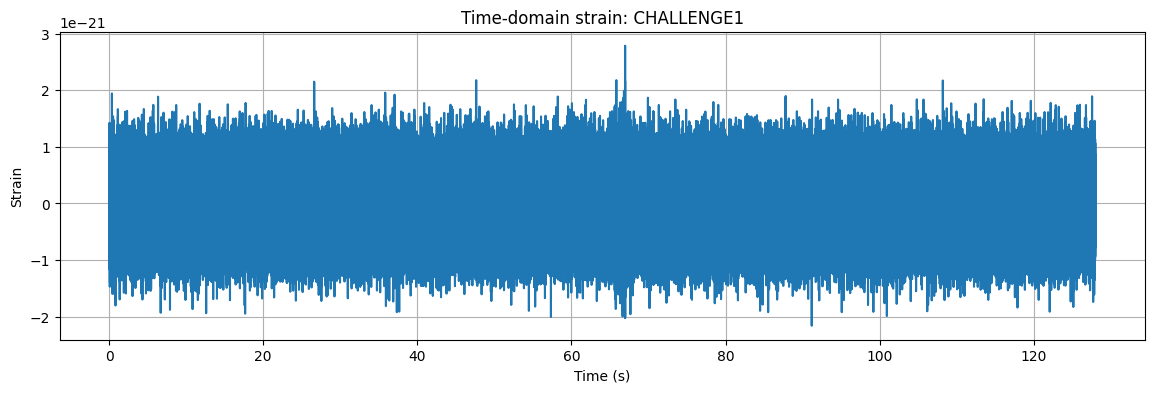

In [5]:
plt.figure(figsize=(14,4))
plt.plot(ts.sample_times, ts)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Time-domain strain: CHALLENGE1")
plt.grid()
plt.show()

### Plot a spectrogram (or q-transform) of the data, and try to identify the signal.

In [6]:
# Highpass filter and whiten the data
ts_filtered = highpass(ts, 15.0)
ts_whitened = ts_filtered.whiten(4, 4)

# Create Q-transform
times, freqs, qplane = ts_whitened.qtransform(
    delta_t=0.001,
    logfsteps=100,
    qrange=(4, 64),
    frange=(20, 512)
)

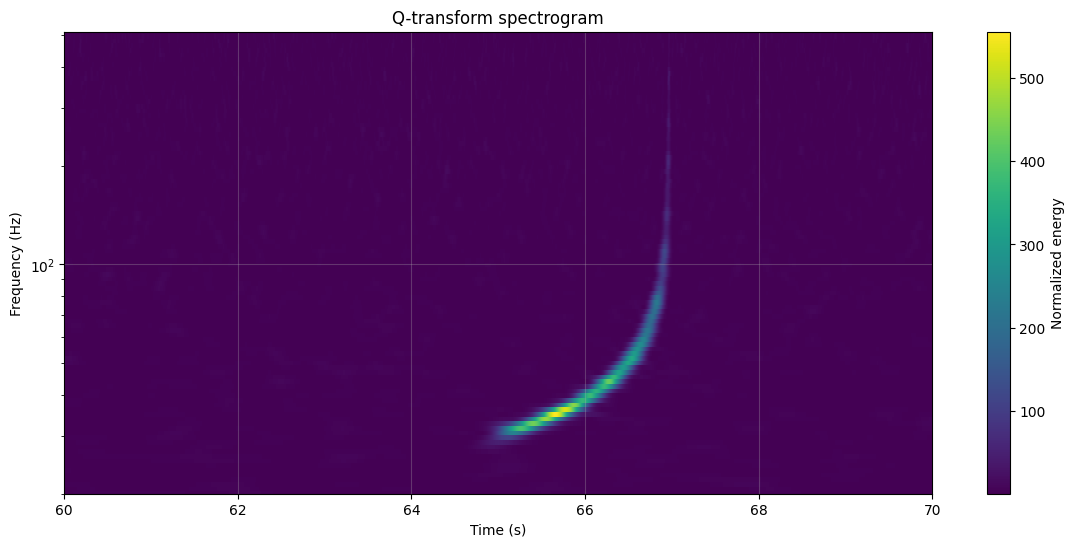

In [7]:
# Plot
plt.figure(figsize=(14, 6))
plt.pcolormesh(times, freqs, qplane, cmap='viridis', shading='auto')
plt.colorbar(label='Normalized energy')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Q-transform spectrogram")
plt.yscale('log')
plt.ylim(20, 512)
plt.xlim(60, 70)
plt.grid(alpha=0.3)
plt.show()

### What is the time of the merger?

In [8]:
# Merging Time
peak_index = np.argmax(abs(ts))
merger_time = ts.sample_times[peak_index]
print("Estimated merger time:", merger_time)

Estimated merger time: 66.966552734375


---